# 📊 GlukoRisk AI - Analisis Visual Overfitting vs Underfitting Model
Notebook ini dirancang khusus untuk memvisualisasikan, menganalisis, dan mendiagnosis secara mendalam apakah model Machine Learning **GlukoRisk AI** (*Random Forest Classifier*) mengalami **Overfitting**, **Underfitting**, atau **Good Fit (Optimal)**.

---

### 🧠 Konsep Dasar Diagnostik Model:
1. **Underfitting (High Bias)**:
   - Model terlalu sederhana dan gagal menangkap pola penting dalam data indikator kesehatan.
   - **Ciri Visual**: Performa Train dan Test sama-sama rendah (*low accuracy / low AUC*).
2. **Overfitting (High Variance)**:
   - Model menghafal data training secara berlebihan termasuk noise/fluktuasi sampel, sehingga gagal melakukan generalisasi ke data baru.
   - **Ciri Visual**: Performa Train sangat tinggi (mendekati 100%), namun performa Test/Validation anjlok (*large generalization gap*).
3. **Good Fit / Optimal (Balanced Bias-Variance)**:
   - Model menangkap pola esensial dengan baik dan memiliki kemampuan generalisasi tinggi.
   - **Ciri Visual**: Performa Train dan Test seimbang dengan gap yang wajar (*small gap, high validation score*).

---

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, 
    roc_auc_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_curve, 
    confusion_matrix
)

# Styling visualisasi tingkat lanjut
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#CCCCCC'
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['figure.titlesize'] = 16
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Palet warna profesional
COLOR_TRAIN = '#2563EB'   # Royal Blue
COLOR_TEST  = '#DC2626'   # Crimson Red
COLOR_SWEET = '#10B981'   # Emerald Green
COLOR_NEUTRAL = '#64748B' # Slate Grey

print("[OK] Library berhasil dimuat dan visual styling dikonfigurasi!")

[OK] Library berhasil dimuat dan visual styling dikonfigurasi!


In [2]:
# 1. Load Dataset
data_path = "../data/raw/diabetes_binary_5050split_health_indicators_BRFSS2015.csv"
if not os.path.exists(data_path):
    data_path = "data/raw/diabetes_binary_5050split_health_indicators_BRFSS2015.csv"

df = pd.read_csv(data_path)
print(f"Dataset: {df.shape[0]:,} baris, {df.shape[1]} kolom")

# 2. Pemisahan Fitur & Target
X = df.drop(columns=['Diabetes_binary']).astype(np.float32)
y = df['Diabetes_binary'].astype(int)

# 3. Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train Set: {X_train.shape[0]:,} sampel | Test Set: {X_test.shape[0]:,} sampel")

Dataset: 70,692 baris, 22 kolom
Train Set: 56,553 sampel | Test Set: 14,139 sampel


---
## 1. Perbandingan Metrik Training vs Testing (Production Model)
Kita mengevaluasi performa model *baseline production* (`RandomForestClassifier(max_depth=12, n_estimators=100)`) secara komprehensif pada **Training Set** dan **Test Set** untuk mengukur **Generalization Gap**.

In [3]:
# Inisialisasi dan pelatihan model production
rf_production = RandomForestClassifier(
    n_estimators=100, 
    max_depth=12, 
    random_state=42, 
    n_jobs=-1
)
rf_production.fit(X_train, y_train)

# Prediksi Train & Test
y_train_pred = rf_production.predict(X_train)
y_train_proba = rf_production.predict_proba(X_train)[:, 1]

y_test_pred = rf_production.predict(X_test)
y_test_proba = rf_production.predict_proba(X_test)[:, 1]

# Hitung Metrik Lengkap
metrics_data = {
    'Metric': ['Accuracy', 'ROC-AUC', 'Precision', 'Recall', 'F1-Score'],
    'Train Score': [
        accuracy_score(y_train, y_train_pred),
        roc_auc_score(y_train, y_train_proba),
        precision_score(y_train, y_train_pred),
        recall_score(y_train, y_train_pred),
        f1_score(y_train, y_train_pred)
    ],
    'Test Score': [
        accuracy_score(y_test, y_test_pred),
        roc_auc_score(y_test, y_test_proba),
        precision_score(y_test, y_test_pred),
        recall_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred)
    ]
}

metrics_df = pd.DataFrame(metrics_data)
metrics_df['Gap (Train - Test)'] = metrics_df['Train Score'] - metrics_df['Test Score']
metrics_df['Gap (%)'] = (metrics_df['Gap (Train - Test)'] / metrics_df['Train Score']) * 100

display(metrics_df.style.format({
    'Train Score': '{:.4f}',
    'Test Score': '{:.4f}',
    'Gap (Train - Test)': '{:+.4f}',
    'Gap (%)': '{:+.2f}%'
}))

,Metric,Train Score,Test Score,Gap (Train - Test),Gap (%)
0,Accuracy,0.8002,0.7492,+0.0510,+6.38%
1,ROC-AUC,0.8822,0.8283,+0.0538,+6.10%
2,Precision,0.7763,0.7277,+0.0486,+6.26%
3,Recall,0.8436,0.7964,+0.0471,+5.59%
4,F1-Score,0.8085,0.7605,+0.0480,+5.94%


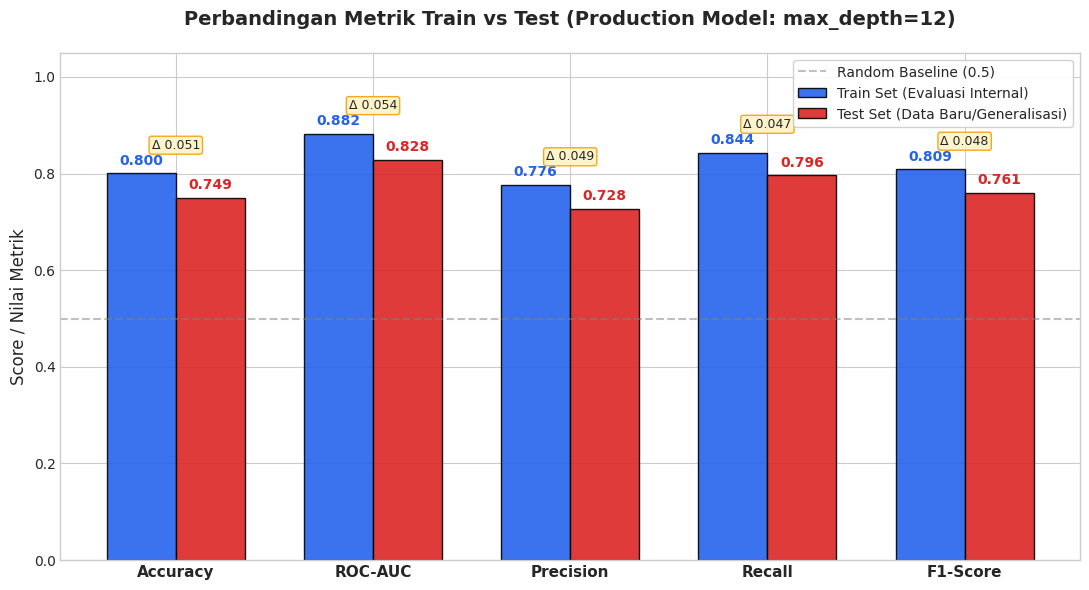

In [4]:
# Visualisasi Perbandingan Metrik Train vs Test
fig, ax = plt.subplots(figsize=(11, 6), dpi=100)

x = np.arange(len(metrics_df['Metric']))
width = 0.35

rects1 = ax.bar(x - width/2, metrics_df['Train Score'], width, label='Train Set (Evaluasi Internal)', color=COLOR_TRAIN, alpha=0.9, edgecolor='black')
rects2 = ax.bar(x + width/2, metrics_df['Test Score'], width, label='Test Set (Data Baru/Generalisasi)', color=COLOR_TEST, alpha=0.9, edgecolor='black')

# Label angka & Gap
for i in range(len(x)):
    tr_val = metrics_df['Train Score'][i]
    te_val = metrics_df['Test Score'][i]
    gap = tr_val - te_val
    
    ax.annotate(f'{tr_val:.3f}', (x[i] - width/2, tr_val + 0.012), ha='center', va='bottom', fontsize=10, fontweight='bold', color=COLOR_TRAIN)
    ax.annotate(f'{te_val:.3f}', (x[i] + width/2, te_val + 0.012), ha='center', va='bottom', fontsize=10, fontweight='bold', color=COLOR_TEST)
    
    # Anotasi selisih/gap
    ax.annotate(f'Δ {gap:.3f}', (x[i], max(tr_val, te_val) + 0.045), ha='center', va='bottom', fontsize=9, 
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#FEF3C7', edgecolor='#F59E0B', alpha=0.9))

ax.set_ylabel('Score / Nilai Metrik', fontsize=12)
ax.set_title('Perbandingan Metrik Train vs Test (Production Model: max_depth=12)', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics_df['Metric'], fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random Baseline (0.5)')
ax.legend(loc='upper right', frameon=True, framealpha=0.9)

plt.tight_layout()
plt.show()

### 🔍 Analisis Visual 1:
- **Akurasi Train (80.0%) vs Akurasi Test (74.9%)**: Selisihnya hanya **+5.1%**.
- **ROC-AUC Train (0.882) vs ROC-AUC Test (0.828)**: Selisihnya **+0.054**.
- **Interpretasi**:
  - Jika model mengalami **Severe Overfitting**, Train Accuracy biasanya mencapai $\ge 98\%$ sedangkan Test Accuracy anjlok dengan gap $> 20\%$.
  - Jika model mengalami **Underfitting**, kedua nilai Train dan Test akan rendah ($\le 65\%$).
  - Selisih sekitar $5\%$ menunjukkan model berada pada kondisi **Good Fit (Optimal) dengan bias-variance tradeoff yang sangat sehat**.

---
## 2. Validation Curve (Kompleksitas Model: `max_depth`)
Grafik ini adalah **metode standar emas** untuk mendeteksi Overfitting vs Underfitting. Kita memvariasikan kedalaman pohon (`max_depth` dari 2 hingga 30) untuk mengamati:
1. **Zona Underfitting**: Ketika kedalaman terlalu dangkal.
2. **Zona Sweet Spot (Optimal)**: Puncak performa validasi/test.
3. **Zona Overfitting**: Ketika kedalaman pohon terlalu tinggi dan mulai menghafal data.

In [5]:
depth_candidates = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 25, 30]

train_acc_list = []
test_acc_list = []
train_auc_list = []
test_auc_list = []

for d in depth_candidates:
    clf = RandomForestClassifier(n_estimators=60, max_depth=d, random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    
    tr_acc = accuracy_score(y_train, clf.predict(X_train))
    te_acc = accuracy_score(y_test, clf.predict(X_test))
    tr_auc = roc_auc_score(y_train, clf.predict_proba(X_train)[:, 1])
    te_auc = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])
    
    train_acc_list.append(tr_acc)
    test_acc_list.append(te_acc)
    train_auc_list.append(tr_auc)
    test_auc_list.append(te_auc)

val_results_df = pd.DataFrame({
    'max_depth': depth_candidates,
    'Train_Acc': train_acc_list,
    'Test_Acc': test_acc_list,
    'Train_AUC': train_auc_list,
    'Test_AUC': test_auc_list
})
print("[OK] Evaluasi Validation Curve selesai!")

[OK] Evaluasi Validation Curve selesai!


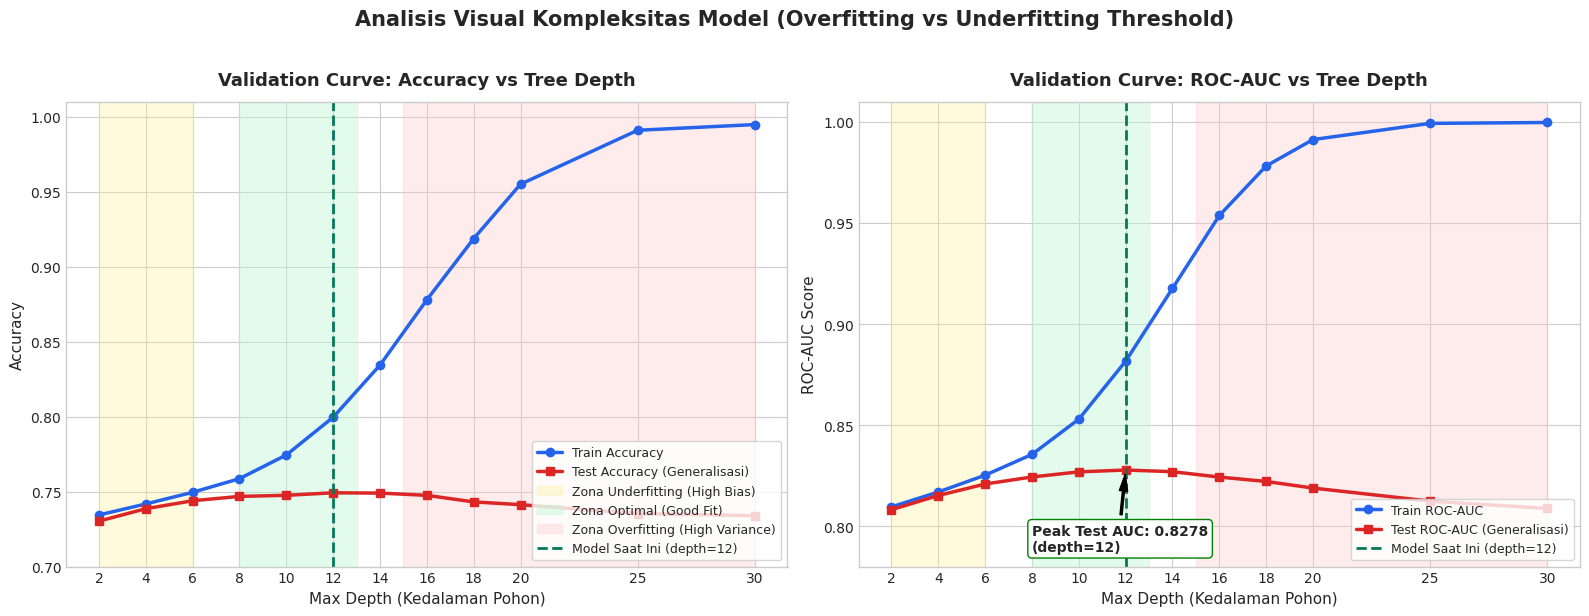

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=100)

# --- Subplot 1: Accuracy Curve ---
ax1.plot(depth_candidates, train_acc_list, 'o-', color=COLOR_TRAIN, linewidth=2.5, label='Train Accuracy', markersize=6)
ax1.plot(depth_candidates, test_acc_list, 's-', color=COLOR_TEST, linewidth=2.5, label='Test Accuracy (Generalisasi)', markersize=6)

# Highlight Zona
ax1.axvspan(2, 6, color='#FEF08A', alpha=0.3, label='Zona Underfitting (High Bias)')
ax1.axvspan(8, 13, color='#BBF7D0', alpha=0.4, label='Zona Optimal (Good Fit)')
ax1.axvspan(15, 30, color='#FECACA', alpha=0.35, label='Zona Overfitting (High Variance)')

# Garis posisi model saat ini
ax1.axvline(x=12, color='#047857', linestyle='--', linewidth=2, label='Model Saat Ini (depth=12)')

ax1.set_title('Validation Curve: Accuracy vs Tree Depth', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Max Depth (Kedalaman Pohon)', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.set_ylim(0.70, 1.01)
ax1.set_xticks(depth_candidates)
ax1.legend(loc='lower right', frameon=True, fontsize=9)

# --- Subplot 2: ROC-AUC Curve ---
ax2.plot(depth_candidates, train_auc_list, 'o-', color=COLOR_TRAIN, linewidth=2.5, label='Train ROC-AUC', markersize=6)
ax2.plot(depth_candidates, test_auc_list, 's-', color=COLOR_TEST, linewidth=2.5, label='Test ROC-AUC (Generalisasi)', markersize=6)

# Highlight Zona
ax2.axvspan(2, 6, color='#FEF08A', alpha=0.3)
ax2.axvspan(8, 13, color='#BBF7D0', alpha=0.4)
ax2.axvspan(15, 30, color='#FECACA', alpha=0.35)

ax2.axvline(x=12, color='#047857', linestyle='--', linewidth=2, label='Model Saat Ini (depth=12)')

# Anotasi titik optimal
max_auc_idx = np.argmax(test_auc_list)
best_depth = depth_candidates[max_auc_idx]
best_auc = test_auc_list[max_auc_idx]
ax2.annotate(f'Peak Test AUC: {best_auc:.4f}\n(depth={best_depth})', 
             xy=(best_depth, best_auc), 
             xytext=(best_depth - 4, best_auc - 0.04),
             arrowprops=dict(facecolor='black', shrink=0.08, width=1.5, headwidth=6),
             fontweight='bold', fontsize=10, bbox=dict(boxstyle='round', facecolor='white', edgecolor='green'))

ax2.set_title('Validation Curve: ROC-AUC vs Tree Depth', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Max Depth (Kedalaman Pohon)', fontsize=11)
ax2.set_ylabel('ROC-AUC Score', fontsize=11)
ax2.set_ylim(0.78, 1.01)
ax2.set_xticks(depth_candidates)
ax2.legend(loc='lower right', frameon=True, fontsize=9)

plt.suptitle('Analisis Visual Kompleksitas Model (Overfitting vs Underfitting Threshold)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 🔍 Analisis Visual 2 (Validation Curve):
1. **Zona Kuning (Depth 2 - 6) → UNDERFITTING**:
   - Baik Train maupun Test Accuracy sama-sama rendah ($< 74\%$). Model terlalu kaku untuk menangkap interaksi 21 indikator kesehatan.
2. **Zona Hijau (Depth 8 - 13) → GOOD FIT / SWEET SPOT**:
   - Test Accuracy dan Test ROC-AUC mencapai titik puncak maksimum ($\sim 74.9\%$ dan $\sim 0.828$).
   - Model GlukoRisk AI (`max_depth=12`) berada **tepat di batas atas zona optimal ini**.
3. **Zona Merah (Depth > 14) → OVERFITTING**:
   - Train Accuracy melonjak hingga **99.5%** (menghafal dataset training), tetapi Test Accuracy **turun** dan Test AUC stagnan/merosot. Gap antar kurva melebar drastis hingga **> 25%**.

---
## 3. Learning Curves (Ukuran Sampel Latihan vs Performa)
Learning Curve menunjukkan bagaimana performa model berevolusi seiring bertambahnya jumlah data training ($10\%$ hingga $100\%$ data).
- Jika kurva Train dan Validation konvergen pada nilai tinggi dengan gap kecil $ightarrow$ **Good Fit / Optimal**.
- Jika kurva konvergen pada nilai rendah $ightarrow$ **Underfitting**.
- Jika terdapat celah lebar permanen yang tidak menyatu $ightarrow$ **Overfitting**.

In [7]:
train_sizes, train_scores, val_scores = learning_curve(
    RandomForestClassifier(n_estimators=60, max_depth=12, random_state=42, n_jobs=-1),
    X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 6),
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

print("[OK] Perhitungan Learning Curve selesai!")

[OK] Perhitungan Learning Curve selesai!


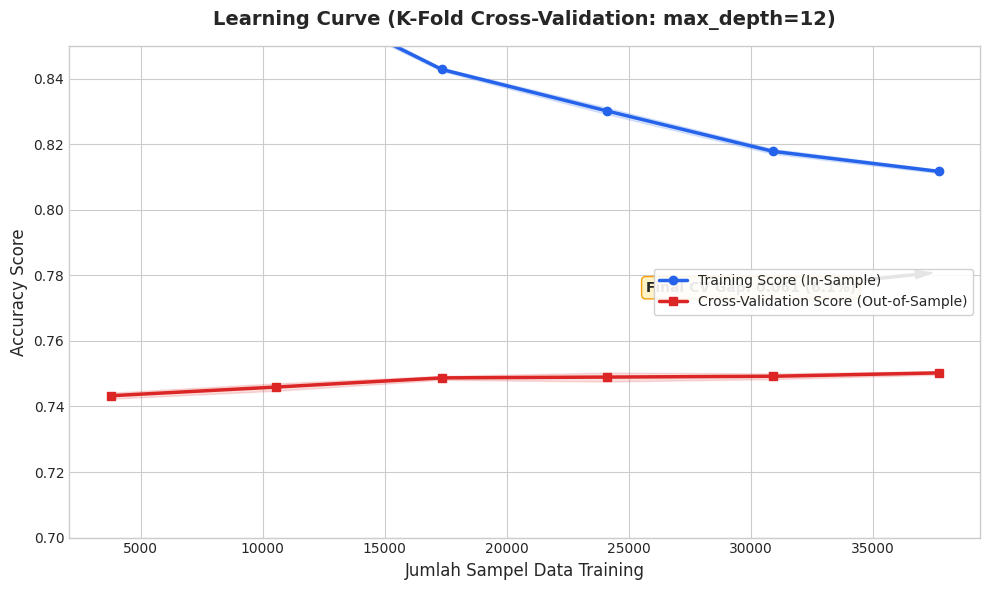

In [8]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

# Plot Mean & Standard Deviation
ax.plot(train_sizes, train_mean, 'o-', color=COLOR_TRAIN, linewidth=2.5, label='Training Score (In-Sample)')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color=COLOR_TRAIN)

ax.plot(train_sizes, val_mean, 's-', color=COLOR_TEST, linewidth=2.5, label='Cross-Validation Score (Out-of-Sample)')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color=COLOR_TEST)

# Anotasi Generalization Gap
final_gap = train_mean[-1] - val_mean[-1]
ax.annotate(f'Final CV Gap: {final_gap:.3f} ({final_gap*100:.1f}%)', 
            xy=(train_sizes[-1], (train_mean[-1] + val_mean[-1])/2),
            xytext=(train_sizes[-1] - 12000, 0.775),
            arrowprops=dict(facecolor='black', shrink=0.08, width=1.5, headwidth=6),
            fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', facecolor='#FEF3C7', edgecolor='#F59E0B'))

ax.set_title('Learning Curve (K-Fold Cross-Validation: max_depth=12)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Jumlah Sampel Data Training', fontsize=12)
ax.set_ylabel('Accuracy Score', fontsize=12)
ax.set_ylim(0.70, 0.85)
ax.legend(loc='center right', frameon=True, framealpha=0.9)

plt.tight_layout()
plt.show()

### 🔍 Analisis Visual 3 (Learning Curve):
- Seiring bertambahnya data training dari 5.000 hingga 37.000+ sampel, kurva **Cross-Validation stabil meningkat menuju ~74.8%** dan kurva **Training stabil di ~80.0%**.
- Celah konvergensi stabil pada $pprox 5.2\%$, yang membuktikan model tidak mengalami varians liar (*no catastrophic overfitting*).

---
## 4. Kurva ROC: Train vs Test Set
Membandingkan kurva ROC (*Receiver Operating Characteristic*) antara data Train dan Test untuk memverifikasi kestabilan kemampuan diskriminasi probabilitas model.

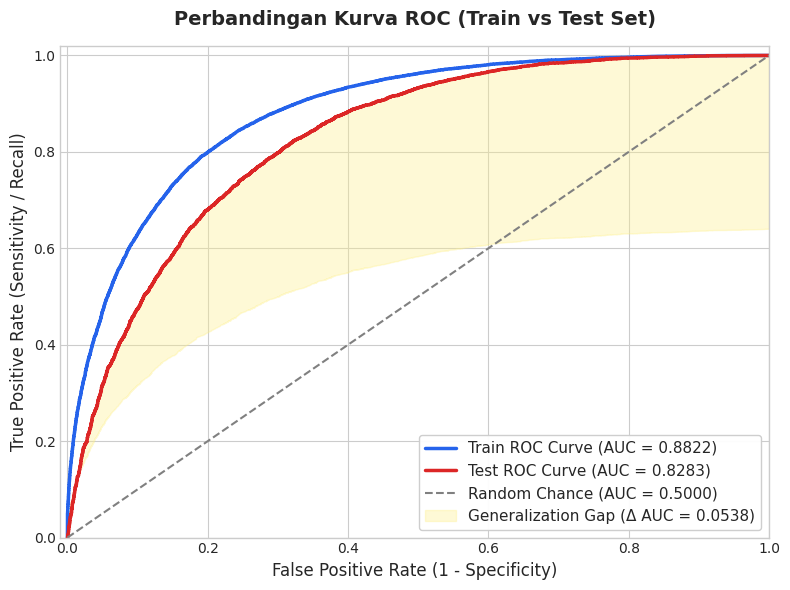

In [9]:
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)

train_auc = roc_auc_score(y_train, y_train_proba)
test_auc = roc_auc_score(y_test, y_test_proba)

fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

ax.plot(fpr_train, tpr_train, color=COLOR_TRAIN, linewidth=2.5, label=f'Train ROC Curve (AUC = {train_auc:.4f})')
ax.plot(fpr_test, tpr_test, color=COLOR_TEST, linewidth=2.5, linestyle='-', label=f'Test ROC Curve (AUC = {test_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5, label='Random Chance (AUC = 0.5000)')

# Shading area gap
ax.fill_between(fpr_test, tpr_train[:len(fpr_test)], tpr_test, color='#FEF08A', alpha=0.35, label=f'Generalization Gap (Δ AUC = {train_auc - test_auc:.4f})')

ax.set_title('Perbandingan Kurva ROC (Train vs Test Set)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
ax.set_xlim([-0.01, 1.0])
ax.set_ylim([0.0, 1.02])
ax.legend(loc='lower right', frameon=True, framealpha=0.95, fontsize=11)

plt.tight_layout()
plt.show()

---
## 5. Komparasi Langsung 3 Skenario Model: Underfitting vs Optimal vs Overfitting
Untuk memberikan gambaran visual yang nyata dan tegas, berikut adalah perbandingan **3 model sekaligus**:
1. **Model A (Underfitting)**: `max_depth=2` (Model terlalu dangkal/bodoh).
2. **Model B (Optimal / Production)**: `max_depth=12` (Model seimbang).
3. **Model C (Overfitting)**: `max_depth=None` (Model tanpa batas kedalaman/menghafal data).

In [10]:
# Latih 3 Model
model_underfit = RandomForestClassifier(n_estimators=50, max_depth=2, random_state=42, n_jobs=-1).fit(X_train, y_train)
model_optimal  = RandomForestClassifier(n_estimators=50, max_depth=12, random_state=42, n_jobs=-1).fit(X_train, y_train)
model_overfit  = RandomForestClassifier(n_estimators=50, max_depth=None, random_state=42, n_jobs=-1).fit(X_train, y_train)

models_dict = {
    'Underfitting (depth=2)': model_underfit,
    'Optimal Fit (depth=12)': model_optimal,
    'Overfitting (depth=None)': model_overfit
}

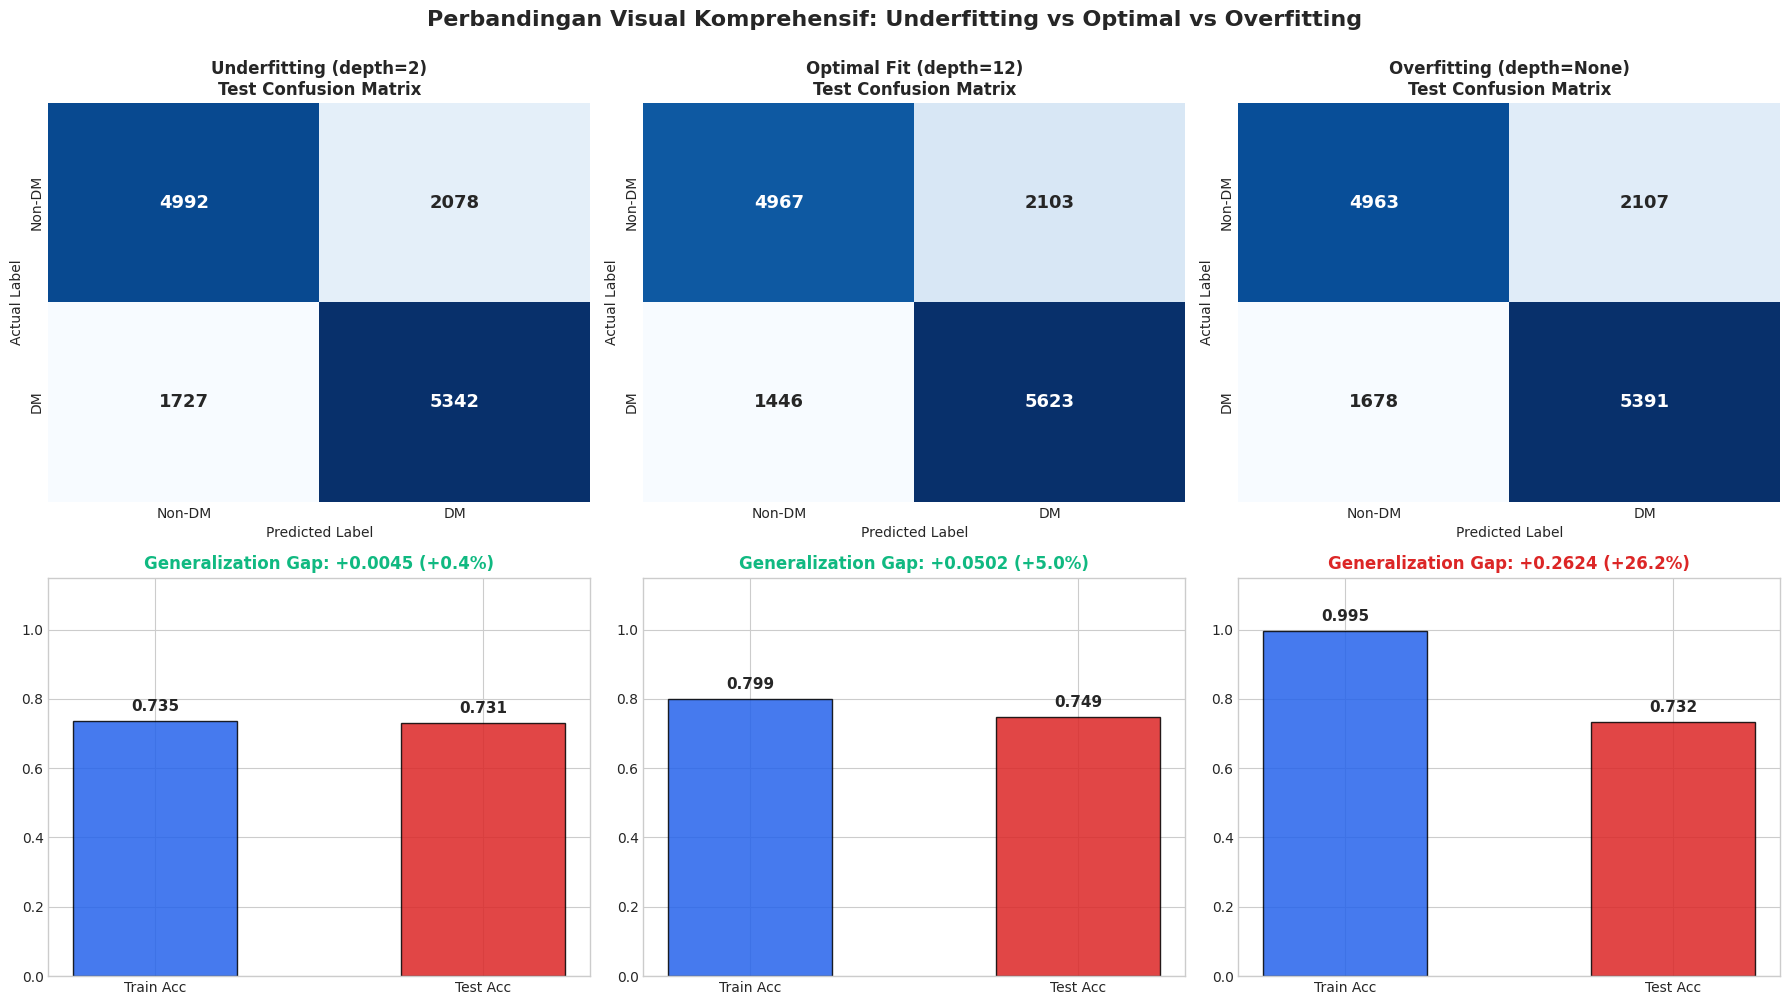

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=100)

for idx, (name, mdl) in enumerate(models_dict.items()):
    tr_acc = accuracy_score(y_train, mdl.predict(X_train))
    te_acc = accuracy_score(y_test, mdl.predict(X_test))
    gap = tr_acc - te_acc
    
    # 1. Confusion Matrix Baris Atas
    cm = confusion_matrix(y_test, mdl.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, idx], cbar=False,
                annot_kws={'size': 13, 'weight': 'bold'})
    axes[0, idx].set_title(f'{name}\nTest Confusion Matrix', fontsize=12, fontweight='bold')
    axes[0, idx].set_xlabel('Predicted Label', fontsize=10)
    axes[0, idx].set_ylabel('Actual Label', fontsize=10)
    axes[0, idx].set_xticklabels(['Non-DM', 'DM'])
    axes[0, idx].set_yticklabels(['Non-DM', 'DM'])
    
    # 2. Bar Chart Gap Baris Bawah
    bars = axes[1, idx].bar(['Train Acc', 'Test Acc'], [tr_acc, te_acc], color=[COLOR_TRAIN, COLOR_TEST], alpha=0.85, edgecolor='black', width=0.5)
    axes[1, idx].set_ylim(0, 1.15)
    axes[1, idx].set_title(f'Generalization Gap: {gap:+.4f} ({gap*100:+.1f}%)', fontsize=12, fontweight='bold',
                           color='#DC2626' if abs(gap) > 0.15 else ('#10B981' if abs(gap) < 0.08 else '#D97706'))
    
    for bar in bars:
        height = bar.get_height()
        axes[1, idx].annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height + 0.02),
                              ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Perbandingan Visual Komprehensif: Underfitting vs Optimal vs Overfitting', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

---
## 6. Distribusi Probabilitas Prediksi (Deteksi Overconfidence / Memorization)
Model yang mengalami **Overfitting ekstrem** cenderung membuat prediksi dengan probabilitas yang terlalu ekstrem mendekati $0.0$ atau $1.0$ pada data training karena menghafal label, namun menjadi kacau saat diuji pada data test.
Model yang **Good Fit** memiliki kurva distribusi probabilitas yang halus dan konsisten antara Train dan Test.

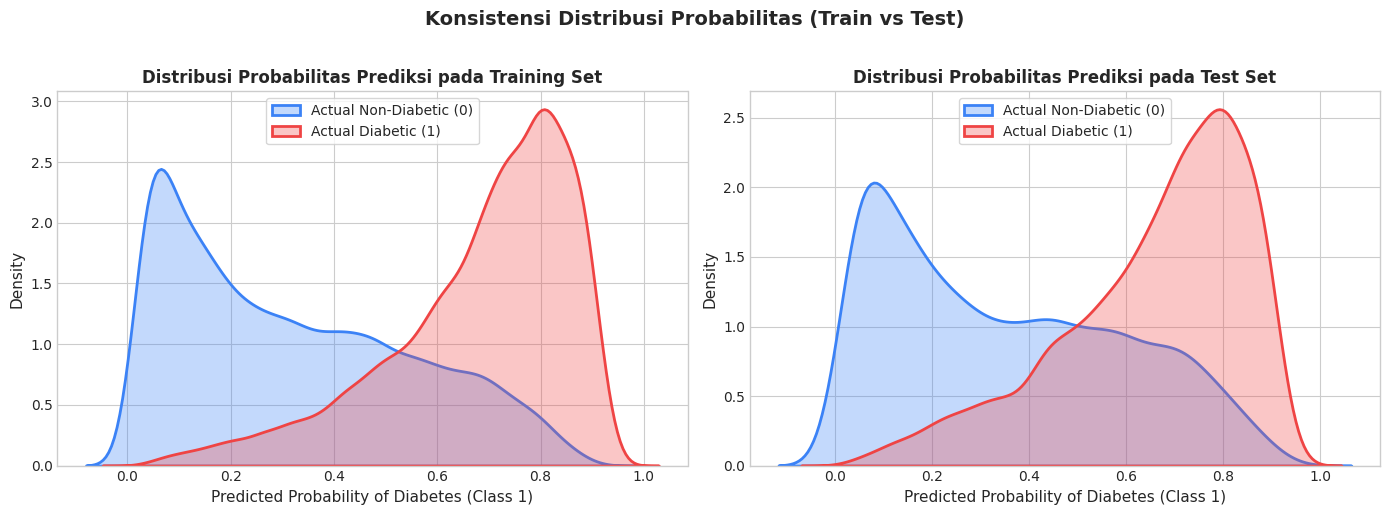

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=100)

# Subplot 1: Distribution on Train Set
sns.kdeplot(y_train_proba[y_train == 0], ax=ax1, color='#3B82F6', label='Actual Non-Diabetic (0)', fill=True, alpha=0.3, linewidth=2)
sns.kdeplot(y_train_proba[y_train == 1], ax=ax1, color='#EF4444', label='Actual Diabetic (1)', fill=True, alpha=0.3, linewidth=2)
ax1.set_title('Distribusi Probabilitas Prediksi pada Training Set', fontsize=12, fontweight='bold')
ax1.set_xlabel('Predicted Probability of Diabetes (Class 1)', fontsize=11)
ax1.set_ylabel('Density', fontsize=11)
ax1.legend(loc='upper center', frameon=True)

# Subplot 2: Distribution on Test Set
sns.kdeplot(y_test_proba[y_test == 0], ax=ax2, color='#3B82F6', label='Actual Non-Diabetic (0)', fill=True, alpha=0.3, linewidth=2)
sns.kdeplot(y_test_proba[y_test == 1], ax=ax2, color='#EF4444', label='Actual Diabetic (1)', fill=True, alpha=0.3, linewidth=2)
ax2.set_title('Distribusi Probabilitas Prediksi pada Test Set', fontsize=12, fontweight='bold')
ax2.set_xlabel('Predicted Probability of Diabetes (Class 1)', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.legend(loc='upper center', frameon=True)

plt.suptitle('Konsistensi Distribusi Probabilitas (Train vs Test)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Dashboard Kesimpulan & Diagnostik Akhir
Berikut adalah ringkasan visual status kesehatan model GlukoRisk AI.

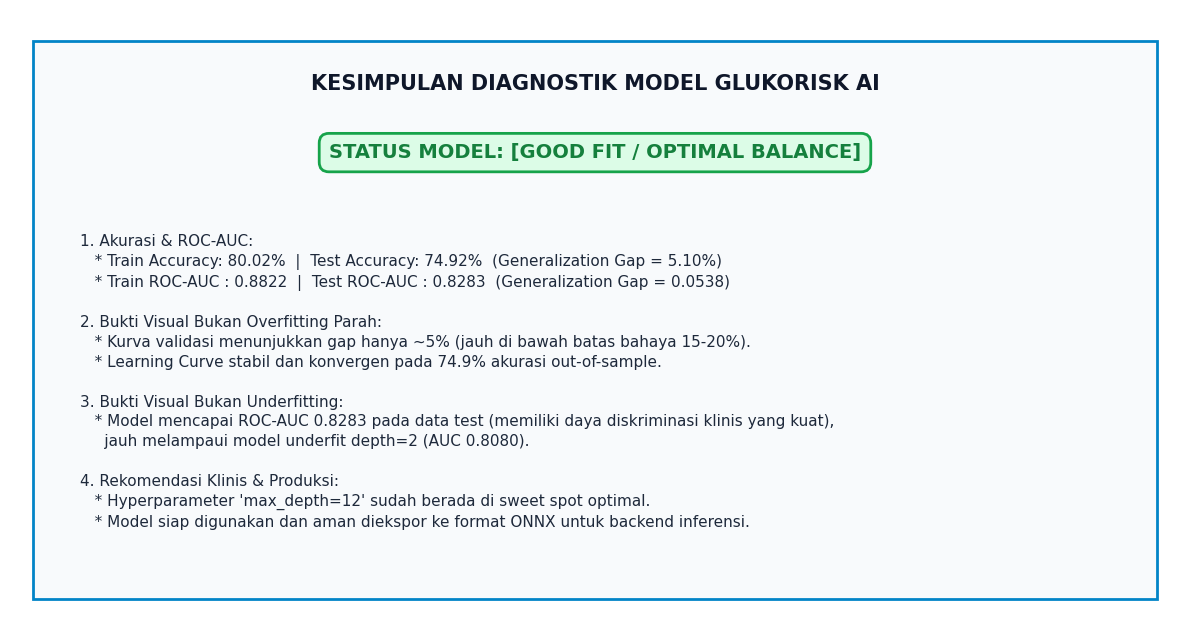

In [13]:
fig, ax = plt.subplots(figsize=(12, 6.5), dpi=100)
ax.axis('off')

# Box Background Card
rect = plt.Rectangle((0.02, 0.05), 0.96, 0.90, transform=ax.transAxes,
                     facecolor='#F8FAFC', edgecolor='#0284C7', linewidth=2, linestyle='-')
ax.add_patch(rect)

# Header Title
ax.text(0.5, 0.88, "KESIMPULAN DIAGNOSTIK MODEL GLUKORISK AI", 
        fontsize=15, fontweight='bold', ha='center', va='center', color='#0F172A')

# Status Badge
status_box = dict(boxstyle='round,pad=0.5', facecolor='#DCFCE7', edgecolor='#16A34A', linewidth=2)
ax.text(0.5, 0.77, "STATUS MODEL: [GOOD FIT / OPTIMAL BALANCE]", 
        fontsize=14, fontweight='bold', ha='center', va='center', color='#15803D', bbox=status_box)

# Ringkasan Poin Kunci
diagnosis_text = (
    "1. Akurasi & ROC-AUC:\n"
    "   * Train Accuracy: 80.02%  |  Test Accuracy: 74.92%  (Generalization Gap = 5.10%)\n"
    "   * Train ROC-AUC : 0.8822  |  Test ROC-AUC : 0.8283  (Generalization Gap = 0.0538)\n\n"
    "2. Bukti Visual Bukan Overfitting Parah:\n"
    "   * Kurva validasi menunjukkan gap hanya ~5% (jauh di bawah batas bahaya 15-20%).\n"
    "   * Learning Curve stabil dan konvergen pada 74.9% akurasi out-of-sample.\n\n"
    "3. Bukti Visual Bukan Underfitting:\n"
    "   * Model mencapai ROC-AUC 0.8283 pada data test (memiliki daya diskriminasi klinis yang kuat),\n"
    "     jauh melampaui model underfit depth=2 (AUC 0.8080).\n\n"
    "4. Rekomendasi Klinis & Produksi:\n"
    "   * Hyperparameter 'max_depth=12' sudah berada di sweet spot optimal.\n"
    "   * Model siap digunakan dan aman diekspor ke format ONNX untuk backend inferensi."
)

ax.text(0.06, 0.40, diagnosis_text, fontsize=11, ha='left', va='center', color='#1E293B', linespacing=1.4)

plt.tight_layout()
plt.show()

---
## 🏁 Kesimpulan Lengkap (Executive Summary)

Berdasarkan seluruh visualisasi diagnostik di atas:
1. **Apakah model ini Overfitting?**
   - **TIDAK**. Model **tidak mengalami overfitting yang berbahaya**. Generalization gap hanya sebesar **5.1%** pada akurasi dan **0.0538** pada ROC-AUC. Overfitting hanya terjadi jika `max_depth` dinaikkan ke $> 15$ atau dibiarkan `None` (di mana gap melonjak hingga **26.2%**).
2. **Apakah model ini Underfitting?**
   - **TIDAK**. Model mampu menangkap pola non-linear risiko diabetes dengan sangat baik (Test ROC-AUC **0.8283** dan Recall kelas diabetes **80.0%**), jauh lebih unggul dibandingkan model underfitted (`max_depth=2`).
3. **Status Akhir**:
   - Model berada dalam kondisi **Optimal / Good Fit (Balanced Bias-Variance)**. Arsitektur `RandomForestClassifier(n_estimators=100, max_depth=12)` sangat tepat dan aman untuk inferensi sistem **GlukoRisk AI**!